# Waze User Churn - 04. Model Interpretability and Business Recommendations

**Project Goal:** To build a machine learning model that predicts user churn risk and supports business-facing retention decisions.

**Notebook 04 Goal:** In this notebook, I will translate the final calibrated churn model from Notebook 03 into business-facing outputs. The focus is not to retrain or reselect the model, but to use the saved churn probabilities to create risk tiers, profile user behavior, interpret model decisions, and propose retention recommendations.

This notebook will cover:

- Loading the final calibrated model and saved artifacts from Notebook 03;
- Validating that the saved prediction outputs align with the final threshold and model metadata;
- Reviewing final test performance as a reference baseline;
- Converting calibrated churn probabilities into Low, Medium, and High Risk tiers;
- Validating whether the risk tiers separate users by observed churn rate;
- Profiling risk tiers using Waze behavioral features;
- Clustering High Risk users into exploratory behavioral sub-segments;
- Interpreting model behavior using permutation importance and Logistic Regression coefficients;
- Translating risk tiers, behavioral profiles, and model interpretation into retention recommendations;
- Saving risk-tiered outputs for reporting, dashboarding, or further analysis.

## 1. Import Libraries and Configurations

Imports the libraries needed for model interpretation, risk-tier analysis, visualization, and artifact loading.

In [1]:
import os
import sys
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    silhouette_score
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 2. Define Paths

In [2]:
# project paths
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = Path("../models")
SRC_DIR = Path("../src")
OUTPUT_DIR = PROCESSED_DIR / "notebook_04_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# output from Notebook 03
MODEL_PATH = MODEL_DIR / "waze_churn_calibrated_model.pkl"
METADATA_PATH = MODEL_DIR / "waze_churn_model_metadata.json"
INPUT_FEATURES_PATH = MODEL_DIR / "waze_churn_input_features.pkl"

CV_RESULTS_PATH = MODEL_DIR / "model_cv_results.csv"
VALIDATION_RESULTS_PATH = MODEL_DIR / "model_validation_results.csv"
THRESHOLD_RESULTS_PATH = MODEL_DIR / "threshold_tuning_results.csv"

TEST_PREDICTIONS_PATH = PROCESSED_DIR / "waze_test_predictions.csv"

print("Model path:", MODEL_PATH)
print("Metadata path:", METADATA_PATH)
print("Input features path:", INPUT_FEATURES_PATH)
print("CV results path:", CV_RESULTS_PATH)
print("Validation results path:", VALIDATION_RESULTS_PATH)
print("Threshold tuning results path:", THRESHOLD_RESULTS_PATH)
print("Test predictions path:", TEST_PREDICTIONS_PATH)
print("Source directory:", SRC_DIR)

Model path: ..\models\waze_churn_calibrated_model.pkl
Metadata path: ..\models\waze_churn_model_metadata.json
Input features path: ..\models\waze_churn_input_features.pkl
CV results path: ..\models\model_cv_results.csv
Validation results path: ..\models\model_validation_results.csv
Threshold tuning results path: ..\models\threshold_tuning_results.csv
Test predictions path: ..\data\processed\waze_test_predictions.csv
Source directory: ..\src


### 2.1. Load Reusable Preprocessing Utilities

The saved model from Notebook 03 contains custom preprocessing logic, including Waze-specific feature engineering and percentile capping.

These functions/classes are defined in `../src/waze_churn_preprocessing.py` so that the model can be loaded safely in this notebook. The same definitions were originally used in Notebook 03.

In [3]:
# add src directory to Python path
if str(SRC_DIR.resolve()) not in sys.path:
    sys.path.append(str(SRC_DIR.resolve()))

from waze_churn_preprocessing import (
    safe_divide,
    add_waze_features,
    PercentileCapper
)

print("Reusable preprocessing utilities loaded successfully.")

Reusable preprocessing utilities loaded successfully.


## 3. Load Final Model Artifacts

Loads the final calibrated model, model metadata, input feature list, and saved test predictions from Notebook 03.

The selected decision threshold is read from the metadata file. The final model is treated as a **churn risk prioritization model**, not a perfect binary classifier. Its calibrated probability output will be used to rank users, assign risk tiers, and support business recommendations.

In [4]:
# load artifacts from Notebook 03
with open(MODEL_PATH, "rb") as f:
    final_model = pickle.load(f)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

with open(INPUT_FEATURES_PATH, "rb") as f:
    input_features = pickle.load(f)

test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)

# extract key metadata
candidate_model_name = metadata["candidate_model_name"]
final_threshold = metadata["final_threshold"]
threshold_selection = metadata["threshold_selection"]
test_metrics_from_metadata = metadata["test_metrics"]

print("Candidate model:", candidate_model_name)
print("Final threshold:", final_threshold)
print("Threshold selection:", threshold_selection)
print("Input feature count:", len(input_features))
print("Test predictions shape:", test_predictions.shape)

Candidate model: LogisticRegression_RobustCapped
Final threshold: 0.19
Threshold selection: minimum validation cost
Input feature count: 18
Test predictions shape: (2860, 34)


In [5]:
# preview saved test predictions
print("Test prediction shape:", test_predictions.shape)
display(test_predictions.head())

Test prediction shape: (2860, 34)


,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,is_high_sessions,is_high_drives,is_high_total_sessions,is_high_driven_km_drives,is_high_duration_minutes_drives,is_high_total_navigations_fav1,is_high_total_navigations_fav2,sessions_per_day_after_onboarding,total_sessions_per_day_after_onboarding,drives_per_activity_day,drives_per_driving_day,km_per_drive,minutes_per_drive,km_per_driving_day,minutes_per_driving_day,percent_sessions_in_last_month,total_favorite_navigations,has_favorite_navigation,favorite_navigations_per_session,actual_churn,predicted_churn,churn_probability,error_type
0,97,78,248.931347,2487,0,0,3005.080443,1760.178418,12,9,Android,0,0,0,0,0,0,0,0.039003,0.100093,6.500000,8.666667,38.526672,22.566390,333.897827,195.575380,0.389666,0,0,0.000000,0,0,0.121454,True Negative
1,11,9,11.918309,1165,0,23,2498.873591,693.884335,6,6,iPhone,0,0,0,0,0,0,0,0.009442,0.010230,1.500000,1.500000,277.652621,77.098259,416.478932,115.647389,0.922950,23,1,1.929804,0,1,0.226505,False Positive
2,30,30,67.009026,1492,17,0,2060.786705,830.545377,17,13,iPhone,0,0,0,0,0,0,0,0.020107,0.044912,1.764706,2.307692,68.692890,27.684846,158.522054,63.888106,0.447701,17,1,0.253697,0,0,0.097636,True Negative
3,32,26,168.116909,1285,0,41,1665.521125,1080.681275,16,14,Android,0,0,0,0,0,0,0,0.024903,0.130830,1.625000,1.857143,64.058505,41.564664,118.965795,77.191520,0.190344,41,1,0.243878,0,0,0.105780,True Negative
4,21,21,96.725381,676,127,9,4230.591087,3170.893085,16,10,iPhone,0,0,0,0,0,0,0,0.031065,0.143085,1.312500,2.100000,201.456718,150.994909,423.059109,317.089309,0.217110,136,1,1.406043,0,0,0.185136,True Negative


### 3.1. Load Supporting Evaluation Tables

The model comparison and threshold tuning tables from Notebook 03 are loaded for reference. They are not used to retrain the model, but they help keep Notebook 04 aligned with the final modeling decisions.

In [6]:
supporting_tables = {}

for name, path in {
    "cv_results": CV_RESULTS_PATH,
    "validation_results": VALIDATION_RESULTS_PATH,
    "threshold_tuning_results": THRESHOLD_RESULTS_PATH
}.items():
    if path.exists():
        supporting_tables[name] = pd.read_csv(path)
        print(f"Loaded {name}: {path} | shape={supporting_tables[name].shape}")
    else:
        print(f"Missing {name}: {path}")

Loaded cv_results: ..\models\model_cv_results.csv | shape=(8, 8)
Loaded validation_results: ..\models\model_validation_results.csv | shape=(8, 9)
Loaded threshold_tuning_results: ..\models\threshold_tuning_results.csv | shape=(91, 12)


### 3.2. Validate Prediction Columns

The saved prediction file from Notebook 03 has been loaded successfully and contains the model inputs, engineered behavioral features, actual labels, predicted labels, and calibrated churn probabilities.

Before moving into risk tiering and interpretation, I will verify the key columns needed for Notebook 04:

- `actual_churn`: true churn label on the test set;
- `churn_probability`: calibrated churn probability from the final model;
- `predicted_churn`: final prediction saved from Notebook 03.

I will also recreate the threshold-based prediction using the final threshold from metadata. This is a consistency check to make sure the saved predictions are aligned with the final decision rule selected in Notebook 03.

In [7]:
# validate key columns needed for Notebook 04
required_prediction_cols = [
    "actual_churn",
    "churn_probability",
    "predicted_churn"
]

missing_cols = [col for col in required_prediction_cols if col not in test_predictions.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in {TEST_PREDICTIONS_PATH}: {missing_cols}")

# standardize dtypes
test_predictions["actual_churn"] = test_predictions["actual_churn"].astype(int)
test_predictions["churn_probability"] = test_predictions["churn_probability"].astype(float)
test_predictions["predicted_churn"] = test_predictions["predicted_churn"].astype(int)

# recreate prediction from the final metadata threshold
test_predictions["predicted_churn_threshold"] = (test_predictions["churn_probability"] >= final_threshold).astype(int)

# check consistency between saved predictions and metadata threshold
prediction_mismatch = (test_predictions["predicted_churn"] != test_predictions["predicted_churn_threshold"]).sum()

print("Required columns found:", required_prediction_cols)
print("Prediction mismatches vs metadata threshold:", prediction_mismatch)

display_cols = [
    "actual_churn",
    "churn_probability",
    "predicted_churn",
    "predicted_churn_threshold"
]

if "error_type" in test_predictions.columns:
    display_cols.append("error_type")

display(test_predictions[display_cols].head())

Required columns found: ['actual_churn', 'churn_probability', 'predicted_churn']
Prediction mismatches vs metadata threshold: 0


,actual_churn,churn_probability,predicted_churn,predicted_churn_threshold,error_type
0,0,0.121454,0,0,True Negative
1,0,0.226505,1,1,False Positive
2,0,0.097636,0,0,True Negative
3,0,0.105780,0,0,True Negative
4,0,0.185136,0,0,True Negative


## 4. Review Final Prediction Performance

Before moving into risk tiering and business interpretation, I first review the final test performance saved from Notebook 03.

This step ensures that Notebook 04 is using the same calibrated churn probabilities and the same final decision threshold selected during model evaluation. It also provides a performance baseline for interpreting the risk tiers and user segments in the following sections.

The goal is not to retrain or reselect the model, but to confirm the final prediction outputs before translating them into business-facing insights.

In [8]:
y_test = test_predictions["actual_churn"]
y_proba = test_predictions["churn_probability"]
y_pred = test_predictions["predicted_churn_threshold"]

test_metrics = {
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}

test_metrics_df = pd.DataFrame([test_metrics]).T.reset_index()
test_metrics_df.columns = ["metric", "value"]
display(test_metrics_df)

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["retained", "churned"], zero_division=0))

,metric,value
0,precision,0.313953
1,recall,0.639053
2,f1,0.421053
3,f2,0.529412
4,roc_auc,0.741538
5,pr_auc,0.367792


Classification report:
              precision    recall  f1-score   support

    retained       0.90      0.70      0.79      2353
     churned       0.31      0.64      0.42       507

    accuracy                           0.69      2860
   macro avg       0.61      0.67      0.60      2860
weighted avg       0.80      0.69      0.72      2860



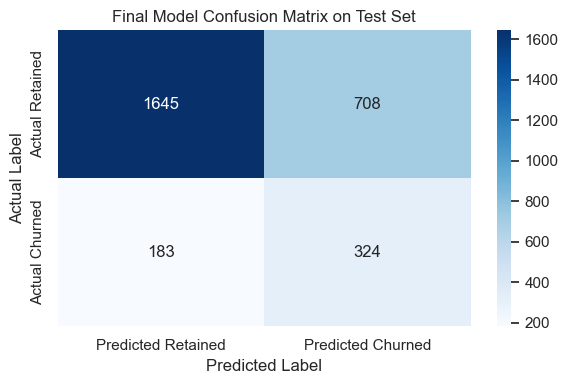

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Retained", "Predicted Churned"],
    yticklabels=["Actual Retained", "Actual Churned"]
)
plt.title("Final Model Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**Final performance interpretation**

The final model is better interpreted as a **churn risk prioritization tool** rather than a perfect binary classifier.

On the test set, the model captures **324 out of 507 actual churned users**, giving a churn recall of **63.9%**. This means the model is able to identify a meaningful share of users who eventually churned.

However, the model also flags **708 retained users** as churned. This leads to a churn precision of **31.4%**, meaning that not every flagged user will actually churn. This is expected in an imbalanced churn problem, but it also confirms why the model output should be used for prioritization rather than automatic intervention.

The F2-score is **0.529**, which reflects the project objective of giving more weight to recall while still penalizing excessive false positives. The ROC-AUC of **0.742** suggests that the model has a reasonable ability to rank churned users above retained users. The PR-AUC of **0.368** is modest, but still informative because churn is the minority class.

Overall, the model provides useful churn risk signals, but its predictions should not be treated as absolute decisions. Instead, the calibrated churn probabilities should be combined with risk tiers, behavioral profiles, and campaign capacity to support more selective retention actions.

## 5. Churn Probability Distribution

This section visualizes the distribution of calibrated churn probabilities produced by the final model.

The goal is to understand whether actual churned users generally receive higher risk scores than retained users, and how much overlap remains between the two groups.

This is important because this notebook uses churn probability as a **risk prioritization score**, not just as an input for binary classification. If churned users tend to concentrate at higher probability ranges, the model can support risk tiering and targeted retention actions. If there is substantial overlap, the risk tiers should be interpreted carefully and combined with behavioral context.

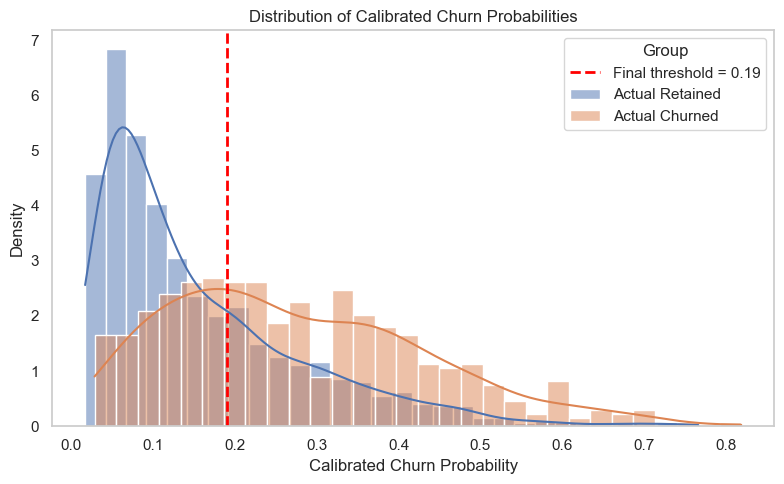

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=test_predictions[test_predictions["actual_churn"] == 0],
    x="churn_probability", bins=30, kde=True, stat="density", alpha=0.5, label="Actual Retained"
)
sns.histplot(
    data=test_predictions[test_predictions["actual_churn"] == 1],
    x="churn_probability", bins=30, kde=True, stat="density", alpha=0.5, label="Actual Churned"
)
plt.axvline(final_threshold, color="red", linestyle="--", linewidth=2, label=f"Final threshold = {final_threshold:.2f}")
plt.title("Distribution of Calibrated Churn Probabilities")
plt.xlabel("Calibrated Churn Probability")
plt.ylabel("Density")
plt.legend(title="Group")
plt.tight_layout()
plt.grid(False)
plt.show()

In [11]:
prob_summary = test_predictions.groupby("actual_churn")["churn_probability"].describe()
display(prob_summary)

,count,mean,std,min,25%,50%,75%,max
actual_churn,,,,,,,,
0,2353.0,0.155370,0.125071,0.017002,0.060693,0.111255,0.212492,0.766288
1,507.0,0.275758,0.157627,0.028529,0.149000,0.250634,0.382044,0.818750


**Probability distribution insight**

Actual churned users generally receive higher churn probabilities than retained users. Retained users have a mean probability of **0.155** and median of **0.111**, while churned users have a higher mean of **0.276** and median of **0.251**.

However, the two distributions still overlap, meaning some retained users look risky and some churned users receive low scores. This is expected because the dataset only contains snapshot behavioral features and cannot capture every churn driver.

The final threshold of **0.19** is lower than 0.5 because churn is the minority class and the goal is early risk detection. Therefore, churn probability should be interpreted as a **risk prioritization score**, not a guaranteed prediction.

## 6. Risk Tier Assignment

Instead of relying only on the binary churn prediction, I will convert calibrated churn probabilities into business-facing risk tiers.

This is useful because the model is intended to support **risk prioritization**, not automatic retention decisions. In practice, retention resources are limited, so the business team needs to know which users should be reviewed or targeted first.

I will use percentile-based risk tiers:

- **High Risk**: users in the top 10% of churn probabilities;
- **Medium Risk**: users in the next 20%;
- **Low Risk**: users in the remaining 70%.

This approach prioritizes users by relative churn risk and avoids depending too heavily on fixed probability cutoffs. It is especially practical when campaign capacity is limited or not yet clearly defined.

In [12]:
# percentile-based risk tiering
high_cutoff = test_predictions["churn_probability"].quantile(0.90)
medium_cutoff = test_predictions["churn_probability"].quantile(0.70)

print("Medium risk cutoff:", medium_cutoff)
print("High risk cutoff:", high_cutoff)

def assign_risk_tier(prob):
    if prob >= high_cutoff:
        return "High Risk"
    elif prob >= medium_cutoff:
        return "Medium Risk"
    else:
        return "Low Risk"

test_predictions["risk_tier"] = test_predictions["churn_probability"].apply(assign_risk_tier)

risk_order = ["Low Risk", "Medium Risk", "High Risk"]
test_predictions["risk_tier"] = pd.Categorical(test_predictions["risk_tier"], categories=risk_order, ordered=True)

display(test_predictions[["actual_churn", "churn_probability", "risk_tier"]].head())

Medium risk cutoff: 0.2177244899314005
High risk cutoff: 0.38222691168374967


,actual_churn,churn_probability,risk_tier
0,0,0.121454,Low Risk
1,0,0.226505,Medium Risk
2,0,0.097636,Low Risk
3,0,0.105780,Low Risk
4,0,0.185136,Low Risk


## 7. Validate Risk Tiers

After assigning risk tiers, I will check whether the tiers behave as expected on the test set.

A useful risk-tiering system should separate users by observed churn rate. In other words, users assigned to higher-risk tiers should have higher actual churn rates:

```text
High Risk churn rate > Medium Risk churn rate > Low Risk churn rate
```
This validation step is important because risk tiers are only useful for business prioritization if they meaningfully rank users by churn risk. If the pattern does not hold, the tiering logic should not be used for retention recommendations without further adjustment.

In [13]:
risk_summary = (
    test_predictions
    .groupby("risk_tier", observed=False)
    .agg(
        users=("actual_churn", "count"),
        churned_users=("actual_churn", "sum"),
        churn_rate=("actual_churn", "mean"),
        avg_probability=("churn_probability", "mean"),
        min_probability=("churn_probability", "min"),
        max_probability=("churn_probability", "max")
    ).reset_index()
)

risk_summary["churn_rate_pct"] = risk_summary["churn_rate"] * 100
risk_summary["avg_probability_pct"] = risk_summary["avg_probability"] * 100

display(risk_summary)

,risk_tier,users,churned_users,churn_rate,avg_probability,min_probability,max_probability,churn_rate_pct,avg_probability_pct
0,Low Risk,2002,218,0.108891,0.100413,0.017002,0.217566,10.889111,10.041288
1,Medium Risk,572,163,0.284965,0.290379,0.218093,0.382165,28.496503,29.037861
2,High Risk,286,126,0.440559,0.483464,0.382789,0.818750,44.055944,48.346370


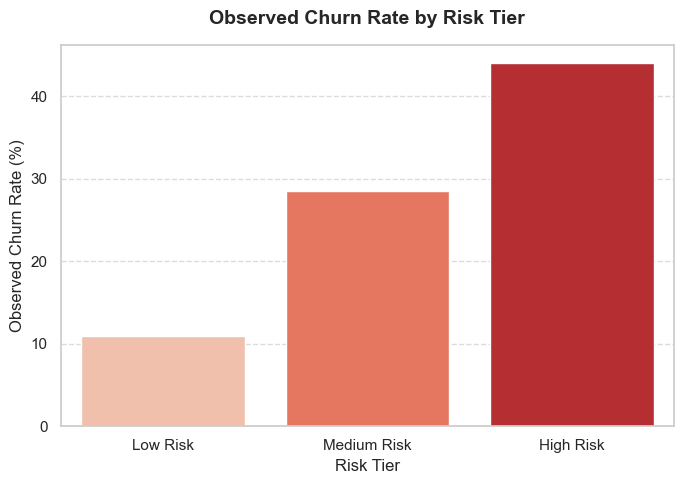

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(data=risk_summary, x="risk_tier", y="churn_rate_pct", order=risk_order, palette="Reds")
plt.title("Observed Churn Rate by Risk Tier", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Risk Tier", fontsize=12)
plt.ylabel("Observed Churn Rate (%)", fontsize=12)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

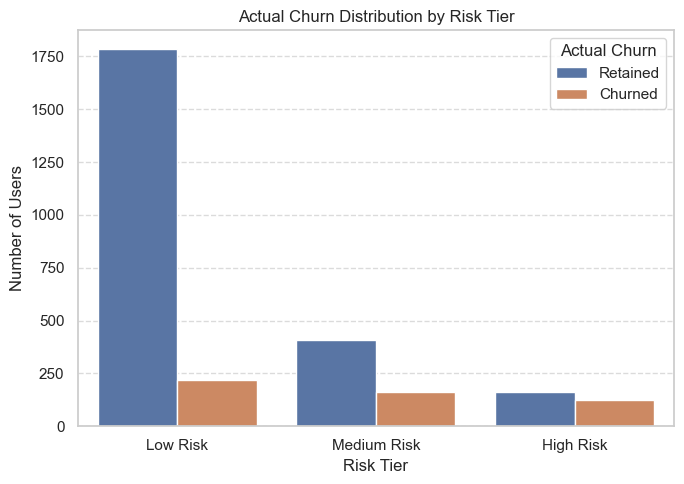

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=test_predictions, x="risk_tier", hue="actual_churn", order=risk_order)
plt.title("Actual Churn Distribution by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Number of Users")
plt.legend(title="Actual Churn", labels=["Retained", "Churned"])
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Risk tier validation insight**

The risk tiers behave as expected: observed churn rate increases clearly from Low Risk to Medium Risk to High Risk.

- **Low Risk** contains 2,002 users with an observed churn rate of **10.9%**.
- **Medium Risk** contains 572 users with an observed churn rate of **28.5%**.
- **High Risk** contains 286 users with an observed churn rate of **44.1%**.

This confirms that the calibrated churn probabilities are useful for ranking users by relative churn risk. The average predicted probability also increases consistently across tiers, from **10.0%** in Low Risk to **29.0%** in Medium Risk and **48.3%** in High Risk.

The High Risk group is much smaller than the Low Risk group, but it has a substantially higher churn concentration. This makes the tiering approach more practical for business use: instead of targeting every user predicted as churned, the team can prioritize the top-risk segment first and expand to Medium Risk users depending on campaign capacity.

Overall, the risk tiers provide a clearer prioritization framework than binary prediction alone.

## 8. Risk Tier Behavioral Profile

After validating that the risk tiers separate users by observed churn rate, I will profile each tier using Waze behavioral features.

The goal is to understand how High Risk users differ from Medium and Low Risk users in terms of activity frequency, driving frequency, tenure, driving intensity, and favorite navigation behavior.

This step connects the model outputs back to the EDA findings from Notebook 01. In particular, I want to check whether High Risk users show patterns such as lower `activity_days`, lower `driving_days`, shorter tenure, or more concentrated driving behavior.

In [16]:
# behavioral features used for risk-tier profiling
profile_features = [
    # usage volume
    "sessions", "drives", "total_sessions",
    # tenure and consistency
    "n_days_after_onboarding", "activity_days", "driving_days",
    # Driving intensity
    "driven_km_drives", "duration_minutes_drives", "km_per_drive", "minutes_per_drive", "km_per_driving_day", "drives_per_activity_day", "drives_per_driving_day",
    # Favorite navigation / stickiness
    "total_favorite_navigations", "has_favorite_navigation", "percent_sessions_in_last_month"
]

# Keep only columns available in the saved prediction file
profile_features = [col for col in profile_features if col in test_predictions.columns]

print("Number of profile features:", len(profile_features))
print(profile_features)

Number of profile features: 16
['sessions', 'drives', 'total_sessions', 'n_days_after_onboarding', 'activity_days', 'driving_days', 'driven_km_drives', 'duration_minutes_drives', 'km_per_drive', 'minutes_per_drive', 'km_per_driving_day', 'drives_per_activity_day', 'drives_per_driving_day', 'total_favorite_navigations', 'has_favorite_navigation', 'percent_sessions_in_last_month']


In [17]:
risk_profile = test_predictions.groupby("risk_tier", observed=False)[profile_features].median().reset_index()
display(risk_profile)

,risk_tier,sessions,drives,total_sessions,n_days_after_onboarding,activity_days,driving_days,driven_km_drives,duration_minutes_drives,km_per_drive,minutes_per_drive,km_per_driving_day,drives_per_activity_day,drives_per_driving_day,total_favorite_navigations,has_favorite_navigation,percent_sessions_in_last_month
0,Low Risk,54.0,47.0,154.572487,2007.0,20.0,16.0,3513.084865,1469.931793,76.657038,31.641985,235.487033,2.541667,3.127717,96.0,1.0,0.431246
1,Medium Risk,55.0,47.0,154.241997,1460.5,6.0,4.0,3492.131580,1440.788247,74.165454,30.346267,554.141586,7.071429,7.000000,113.0,1.0,0.418379
2,High Risk,74.5,64.0,181.820636,862.0,3.0,1.0,4036.108651,1937.533526,66.334644,28.432969,1442.089479,20.690476,17.250000,178.0,1.0,0.462559


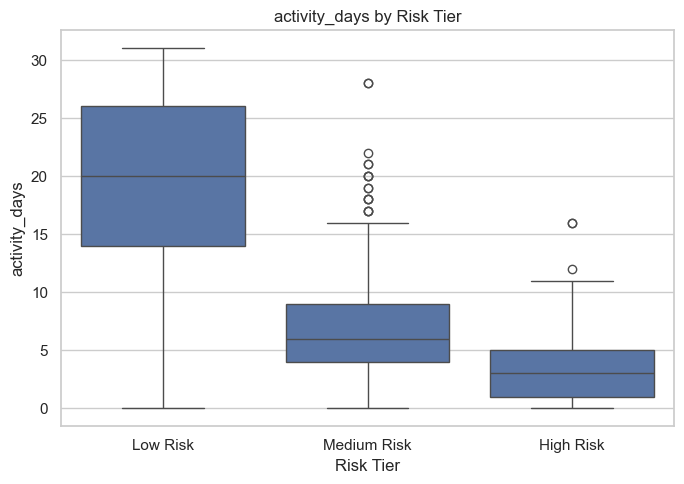

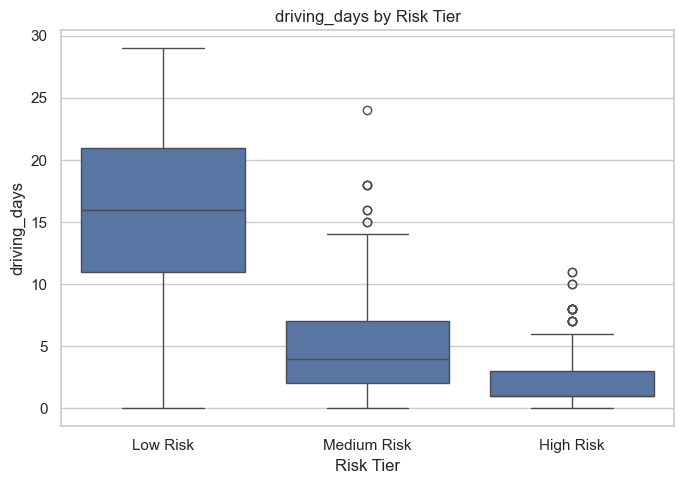

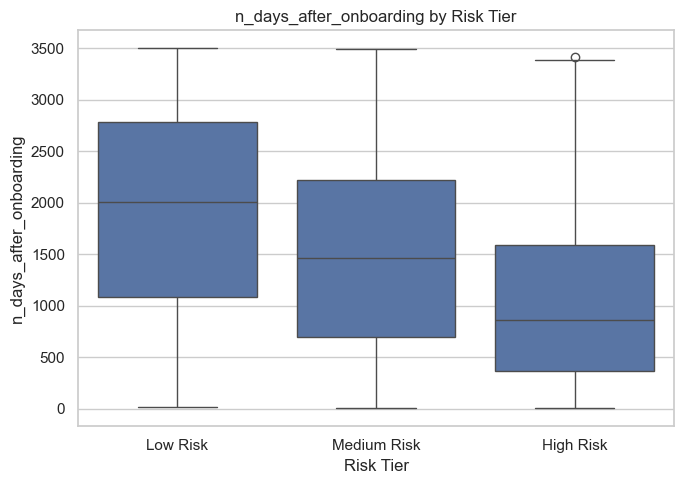

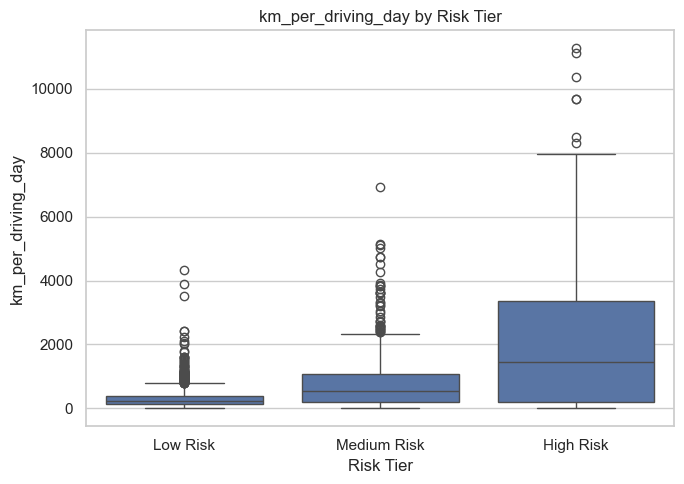

In [18]:
core_features = [c for c in ["activity_days", "driving_days", "n_days_after_onboarding", "km_per_driving_day"] if c in profile_features]
for feature in core_features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=test_predictions, x="risk_tier", y=feature, order=risk_order)
    plt.title(f"{feature} by Risk Tier")
    plt.xlabel("Risk Tier")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

**Risk profile interpretation**

The behavioral profile confirms that the risk tiers are strongly separated by **usage consistency** and **user lifecycle maturity**.

High Risk users have much lower activity frequency than the other groups:

- median `activity_days`: **3** days for High Risk vs. **6** for Medium Risk and **20** for Low Risk;
- median `driving_days`: **1** day for High Risk vs. **4** for Medium Risk and **16** for Low Risk.

High Risk users also have shorter tenure:

- median `n_days_after_onboarding`: **862** days for High Risk;
- **1,460.5** days for Medium Risk;
- **2,007** days for Low Risk.

This supports the main EDA insight from Notebook 01: **churn risk is strongly related to whether users form a regular Waze usage habit**.

Interestingly, High Risk users are not simply low-volume users. They have higher median `sessions`, `drives`, `driven_km_drives`, and `duration_minutes_drives` than Low Risk users. However, this usage is concentrated into fewer active days, shown by much higher `km_per_driving_day`, `drives_per_activity_day`, and `drives_per_driving_day`.

> This suggests that many High Risk users may be **intense but irregular users**. They use Waze heavily when needed, but do not use it consistently enough to show stable product habit.

Overall, the risk-tier profile aligns well with the modeling objective: the model is identifying users with weaker usage consistency, shorter lifecycle maturity, and concentrated driving behavior as higher churn risks.

## 9. High-Risk Behavioral Clustering

Risk tiering identifies **which users should be prioritized first**. Clustering adds another layer by identifying **what types of users exist within the High Risk group**.

This step is exploratory. It does not replace the supervised churn model, and the clusters should not be interpreted as new churn predictions. Instead, clustering is used to create descriptive behavioral sub-segments that can support more targeted retention strategies.

For example, High Risk users may include different behavioral patterns:

- Users with very low activity who have not formed a regular Waze habit;
- Intense but irregular users who drive heavily on only a few days;
- Newer users who have not yet reached stable product adoption.

The goal is to make the High Risk group more actionable. Instead of treating all High Risk users the same way, clustering can help suggest different intervention strategies for different behavioral profiles.

For clustering, I use behavioral features that describe activity consistency, tenure, usage volume, driving intensity, and product stickiness.

The clustering is applied only to High Risk users. This keeps the analysis focused on users who are already prioritized by the supervised churn model. I use 3 clusters to keep the segmentation simple and interpretable for business recommendations, while still allowing more than one high-risk behavior pattern to emerge.

In [19]:
cluster_features = [
    # consistency and tenure
    "activity_days", "driving_days", "n_days_after_onboarding",
    # usage volume
    "sessions", "drives", "total_sessions",
    # driving intensity
    "km_per_driving_day", "drives_per_activity_day", "drives_per_driving_day",
    # product stickiness / recent usage concentration
    "percent_sessions_in_last_month", "total_favorite_navigations", "has_favorite_navigation"
]

# keep only available columns
cluster_features = [col for col in cluster_features if col in test_predictions.columns]

high_risk_cluster_df = (test_predictions[test_predictions["risk_tier"] == "High Risk"].copy())

print("High Risk users available for clustering:", len(high_risk_cluster_df))
print("Number of clustering features:", len(cluster_features))
print("Clustering features:", cluster_features)

High Risk users available for clustering: 286
Number of clustering features: 12
Clustering features: ['activity_days', 'driving_days', 'n_days_after_onboarding', 'sessions', 'drives', 'total_sessions', 'km_per_driving_day', 'drives_per_activity_day', 'drives_per_driving_day', 'percent_sessions_in_last_month', 'total_favorite_navigations', 'has_favorite_navigation']


In [20]:
# prepare clustering matrix
X_cluster = high_risk_cluster_df[cluster_features].replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# use 3 clusters for business-facing segmentation.
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
high_risk_cluster_df["behavior_cluster"] = kmeans.fit_predict(X_cluster_scaled)
sil_score = silhouette_score(
    X_cluster_scaled,
    high_risk_cluster_df["behavior_cluster"]
)
print("Number of clusters:", n_clusters)
print("Silhouette score:", round(sil_score, 4))

cluster_summary = (
    high_risk_cluster_df
    .groupby("behavior_cluster")
    .agg(
        users=("actual_churn", "count"),
        observed_churn_rate=("actual_churn", "mean"),
        avg_churn_probability=("churn_probability", "mean"),
        median_activity_days=("activity_days", "median"),
        median_driving_days=("driving_days", "median"),
        median_tenure_days=("n_days_after_onboarding", "median")
    ).reset_index()
)

cluster_summary["user_share_pct"] = cluster_summary["users"] / cluster_summary["users"].sum() * 100
cluster_summary["observed_churn_rate_pct"] = cluster_summary["observed_churn_rate"] * 100
cluster_summary["avg_churn_probability_pct"] =cluster_summary["avg_churn_probability"] * 100
cluster_profile = high_risk_cluster_df.groupby("behavior_cluster")[cluster_features].median().reset_index()
cluster_summary = cluster_summary.sort_values("avg_churn_probability", ascending=False)
display(cluster_summary)
display(cluster_profile)

Number of clusters: 3
Silhouette score: 0.1909


,behavior_cluster,users,observed_churn_rate,avg_churn_probability,median_activity_days,median_driving_days,median_tenure_days,user_share_pct,observed_churn_rate_pct,avg_churn_probability_pct
1,1,42,0.571429,0.521057,3.0,2.0,1399.0,14.685315,57.142857,52.105702
2,2,193,0.409326,0.483707,2.0,1.0,1030.0,67.482517,40.932642,48.370711
0,0,51,0.450980,0.451583,7.0,4.0,399.0,17.832168,45.098039,45.158335


,behavior_cluster,activity_days,driving_days,n_days_after_onboarding,sessions,drives,total_sessions,km_per_driving_day,drives_per_activity_day,drives_per_driving_day,percent_sessions_in_last_month,total_favorite_navigations,has_favorite_navigation
0,0,7.0,4.0,399.0,69.0,60.0,219.172404,922.192448,8.571429,15.0,0.368994,317.0,1.0
1,1,3.0,2.0,1399.0,280.0,232.0,382.536803,1753.284541,87.333333,128.5,0.783489,122.5,1.0
2,2,2.0,1.0,1030.0,57.0,50.0,153.942211,1707.364410,19.000000,9.5,0.413738,150.0,1.0


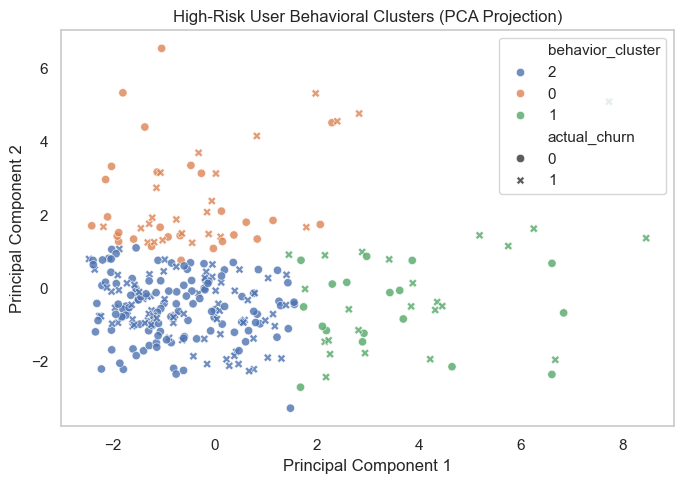

In [21]:
# visualization
if "X_cluster_scaled" in globals() and "behavior_cluster" in high_risk_cluster_df.columns:
    pca = PCA(n_components=2, random_state=42)
    X_cluster_2d = pca.fit_transform(X_cluster_scaled)
    pca_plot_df = pd.DataFrame({
        "PC1": X_cluster_2d[:, 0],
        "PC2": X_cluster_2d[:, 1],
        "behavior_cluster": high_risk_cluster_df["behavior_cluster"].astype(str).values,
        "actual_churn": high_risk_cluster_df["actual_churn"].values
    })
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="behavior_cluster", style="actual_churn", alpha=0.8)
    plt.title("High-Risk User Behavioral Clusters (PCA Projection)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.grid(False)
    plt.show()
else:
    print("Skipping PCA visualization because clustering outputs are not available.")

**High-risk clustering interpretation**

The clustering result provides an exploratory segmentation layer within the High Risk group. The silhouette score is **0.1909**, which suggests that the clusters are only moderately separated. Therefore, the clusters should be interpreted as descriptive behavioral groups, not as a separate predictive model.

The three clusters show different high-risk behavior patterns:

| Cluster | Behavioral Pattern | Observed Churn Rate | Key Characteristics | Suggested Retention Action |
|---|---|---|---|---|
| **Cluster 1**<br>(Intense & Irregular) | Low usage frequency but extremely high usage intensity (`sessions`, `drives`, `drives_per_activity_day`). | **57.1%** (Highest) | Users may rely heavily on Waze only during specific periods or high-demand situations, then stop using the app regularly. | Encourage habit formation through commute setup, saved routes, recurring-trip reminders, and personalized navigation routines. |
| **Cluster 0**<br>(Medium Tenure) | Medium tenure (~399 days) with slightly higher activity consistency than other High Risk groups. | **45.1%** | Users appear to be in a transitional stage where long-term product loyalty has not fully formed. | Improve onboarding continuation, feature education, and user experience feedback collection. |
| **Cluster 2**<br>(Low Frequency) | Largest High Risk segment with extremely low engagement (`activity_days = 2`, `driving_days = 1`). | **40.9%** | Users show weak interaction signals and may be gradually disengaging from the app. | Use re-engagement nudges, reminders, and lightweight incentives to encourage return usage. |

Because all users in this section already belong to the High Risk tier, the observed churn rates should be interpreted as within-tier differences rather than general population churn rates.

## 10. Model Interpretability

This section explains which features the final calibrated model relies on when assigning churn risk.

Since the final model is used as a business-facing risk prioritization model, interpretation is important for understanding whether the model is learning meaningful Waze behavior patterns rather than only producing prediction scores.

I will use two complementary approaches:

1. **Permutation importance** to measure how much model performance decreases when a feature is shuffled.
2. **Coefficient-based interpretation** because the selected candidate model is Logistic Regression.

Permutation importance is model-agnostic and evaluates feature impact through model performance. Coefficients are more direct for Logistic Regression, but they should be interpreted carefully because the final pipeline includes preprocessing steps such as feature engineering, capping, scaling, and encoding.

### 10.1. Permutation Importance

Permutation importance measures how much model performance drops when one feature is randomly shuffled while all other features remain unchanged.

In this notebook, I use **PR-AUC / Average Precision** as the scoring metric because churn is the minority class and PR-AUC is more informative than accuracy for imbalanced classification.

To stay consistent with the saved model pipeline, permutation importance is computed using the original input columns saved from Notebook 03. The pipeline will internally recreate engineered features before making predictions.

In [22]:
# prepare original model input columns for permutation importance
available_input_features = [col for col in input_features if col in test_predictions.columns]
missing_input_features = [col for col in input_features if col not in test_predictions.columns]

print("Number of available input features:", len(available_input_features))
print("Missing input features:", missing_input_features)
if missing_input_features:
    raise ValueError(f"Some input features from Notebook 03 are missing in test_predictions: {missing_input_features}")

X_test_model = test_predictions[available_input_features].copy()
y_test_model = test_predictions["actual_churn"].astype(int)

print("X_test_model shape:", X_test_model.shape)
print("y_test_model shape:", y_test_model.shape)

Number of available input features: 18
Missing input features: []
X_test_model shape: (2860, 18)
y_test_model shape: (2860,)


In [23]:
# Compute permutation importance on a sample for efficiency
sample_size = min(1000, len(X_test_model))
sample_idx = X_test_model.sample(sample_size, random_state=42).index

perm_result = permutation_importance(
    final_model,
    X_test_model.loc[sample_idx],
    y_test_model.loc[sample_idx],
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

perm_importance_df = (
    pd.DataFrame({
        "feature": X_test_model.columns,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
)

display(perm_importance_df.head(20))

,feature,importance_mean,importance_std
0,activity_days,0.065604,0.018056
1,driving_days,0.034949,0.018096
2,n_days_after_onboarding,0.030737,0.012677
3,duration_minutes_drives,0.011209,0.004337
4,driven_km_drives,0.001692,0.002826
5,total_navigations_fav2,0.001384,0.001149
6,is_high_sessions,0.000686,0.000337
7,is_high_total_navigations_fav1,0.000542,0.000182
8,is_high_drives,0.000527,0.000386
9,is_high_total_navigations_fav2,0.000214,0.000854


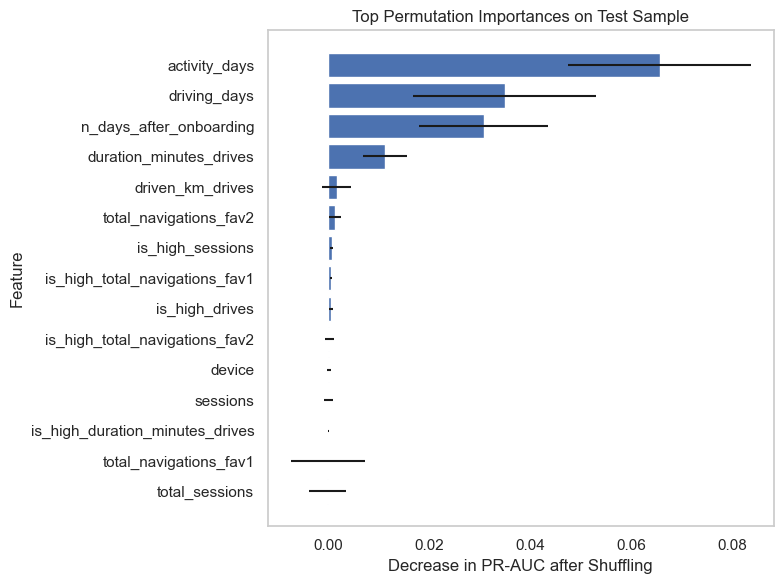

In [24]:
# plot top permutation importances
top_perm = perm_importance_df.head(15).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.title("Top Permutation Importances on Test Sample")
plt.xlabel("Decrease in PR-AUC after Shuffling")
plt.ylabel("Feature")
plt.tight_layout()
plt.grid(False)
plt.show()

**Permutation importance interpretation**

Permutation importance shows that the model relies most strongly on **usage consistency and lifecycle-related features**.

The most important feature is `activity_days`, with the largest decrease in PR-AUC after shuffling (**0.0656**). This means that the number of days a user is active in the app is the strongest original input signal for ranking churn risk.

The next most important features are:

- `driving_days` (**0.0349**): captures how consistently users drive with Waze;
- `n_days_after_onboarding` (**0.0307**): captures user lifecycle maturity;
- `duration_minutes_drives` (**0.0112**): contributes some additional information about driving behavior.

Most other features have much smaller importance values. Features such as `sessions`, `drives`, `total_sessions`, `device`, and high-usage flags contribute little once activity consistency and tenure are already available.

This supports the main project insight from Notebook 01 and the risk-tier profile: churn risk is driven more by **habit formation, activity consistency, and user lifecycle maturity** than by raw usage volume alone.

### 10.2. Logistic Regression Coefficient Interpretation

Since the selected candidate model is `LogisticRegression_RobustCapped`, I can also inspect the model coefficients.

For Logistic Regression:

- a **positive coefficient** means the feature pushes the prediction toward higher churn risk;
- a **negative coefficient** means the feature pushes the prediction toward lower churn risk;
- larger absolute values indicate stronger influence after preprocessing.

However, these coefficients should be interpreted carefully because the final model is wrapped inside a calibrated pipeline and includes preprocessing steps such as feature engineering, capping, scaling, and one-hot encoding. Therefore, the coefficients are useful for understanding model directionality, but they should not be interpreted as causal effects.

In [25]:
def extract_logistic_coefficients(calibrated_model):
    """
    Extract Logistic Regression coefficients from a calibrated sklearn Pipeline.

    The final model is expected to be a CalibratedClassifierCV object that wraps
    a fitted Pipeline. This function unwraps the calibrated model, retrieves the
    Logistic Regression step, and attempts to extract transformed feature names.
    """
    estimator = calibrated_model

    # unwrap CalibratedClassifierCV
    if hasattr(estimator, "calibrated_classifiers_"):
        calibrated_clf = estimator.calibrated_classifiers_[0]

        if hasattr(calibrated_clf, "estimator"):
            estimator = calibrated_clf.estimator
        elif hasattr(calibrated_clf, "base_estimator"):
            estimator = calibrated_clf.base_estimator

    # the unwrapped estimator should be a Pipeline
    if not hasattr(estimator, "named_steps"):
        print("The unwrapped estimator is not a sklearn Pipeline.")
        return pd.DataFrame()

    # extract Logistic Regression step
    if "model" not in estimator.named_steps:
        print("No 'model' step found in the pipeline.")
        return pd.DataFrame()

    model_step = estimator.named_steps["model"]

    if not hasattr(model_step, "coef_"):
        print("The final model step does not expose coefficients.")
        return pd.DataFrame()

    coefficients = model_step.coef_.ravel()

    # try to extract transformed feature names from preprocessing steps
    feature_names = None

    if "preprocessor" in estimator.named_steps:
        try:
            feature_names = estimator.named_steps["preprocessor"].get_feature_names_out()
        except Exception:
            feature_names = None

    if feature_names is None:
        try:
            feature_names = estimator[:-1].get_feature_names_out()
        except Exception:
            feature_names = None

    # fallback if transformed feature names are unavailable
    if feature_names is None or len(feature_names) != len(coefficients):
        feature_names = [f"feature_{i}" for i in range(len(coefficients))]

    coef_df = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefficients,
            "abs_coefficient": np.abs(coefficients)
        })
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    return coef_df


coef_df = extract_logistic_coefficients(final_model)
display(coef_df.head(30))

,feature,coefficient,abs_coefficient
0,num__activity_days,-0.736004,0.736004
1,num__driving_days,-0.580877,0.580877
2,num__n_days_after_onboarding,-0.506492,0.506492
3,num__total_favorite_navigations,0.142054,0.142054
4,num__total_navigations_fav1,0.102291,0.102291
5,num__is_high_total_navigations_fav2,0.071575,0.071575
6,num__is_high_sessions,0.063938,0.063938
7,num__is_high_drives,0.060169,0.060169
8,num__is_high_driven_km_drives,-0.060097,0.060097
9,num__duration_minutes_drives,0.059606,0.059606


In [26]:
if not coef_df.empty:
    top_positive_coef = coef_df.sort_values("coefficient", ascending=False).head(15)[["feature", "coefficient"]].reset_index(drop=True)
    top_negative_coef = coef_df.sort_values("coefficient", ascending=True).head(15)[["feature", "coefficient"]].reset_index(drop=True)

    print("Top features increasing churn risk:")
    display(top_positive_coef)

    print("Top features decreasing churn risk:")
    display(top_negative_coef)
else:
    print("No coefficient table available for interpretation.")

Top features increasing churn risk:


,feature,coefficient
0,num__total_favorite_navigations,0.142054
1,num__total_navigations_fav1,0.102291
2,num__is_high_total_navigations_fav2,0.071575
3,num__is_high_sessions,0.063938
4,num__is_high_drives,0.060169
5,num__duration_minutes_drives,0.059606
6,num__is_high_total_navigations_fav1,0.046407
7,num__drives_per_activity_day,0.042622
8,num__minutes_per_driving_day,0.034836
9,num__km_per_drive,0.032828


Top features decreasing churn risk:


,feature,coefficient
0,num__activity_days,-0.736004
1,num__driving_days,-0.580877
2,num__n_days_after_onboarding,-0.506492
3,num__is_high_driven_km_drives,-0.060097
4,num__is_high_total_sessions,-0.037228
5,num__favorite_navigations_per_session,-0.032839
6,num__has_favorite_navigation,-0.024329
7,num__driven_km_drives,-0.011884
8,num__drives_per_driving_day,-0.010123
9,num__sessions_per_day_after_onboarding,-0.007891


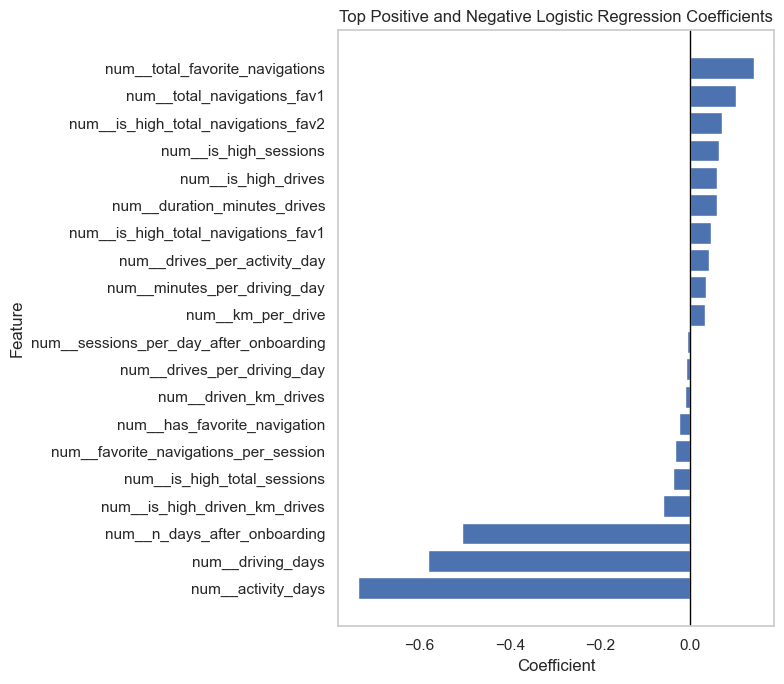

In [27]:
if not coef_df.empty:
    top_coef = pd.concat([
        coef_df.sort_values("coefficient", ascending=False).head(10),
        coef_df.sort_values("coefficient", ascending=True).head(10)
    ])

    top_coef = top_coef.sort_values("coefficient")
    plt.figure(figsize=(8, 7))
    plt.barh(top_coef["feature"], top_coef["coefficient"])
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Top Positive and Negative Logistic Regression Coefficients")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.grid(False)
    plt.show()

**Coefficient interpretation**

The Logistic Regression coefficients are consistent with the main findings from EDA and permutation importance.

The strongest negative coefficients are:

- `activity_days` (**-0.736**)
- `driving_days` (**-0.581**)
- `n_days_after_onboarding` (**-0.506**)

These features reduce predicted churn risk. This means users who are active on more days, drive with Waze on more days, and have longer tenure are more likely to be retained. This strongly supports the central project insight: churn risk is closely related to usage consistency and lifecycle maturity.

The positive coefficients are much smaller in magnitude. Features such as `total_favorite_navigations`, `total_navigations_fav1`, high-usage flags, `duration_minutes_drives`, and `drives_per_activity_day` slightly increase predicted churn risk after preprocessing. This does not necessarily mean these behaviors cause churn. Instead, it suggests that, after controlling for activity frequency and tenure, some users with high concentrated usage or favorite-navigation activity may still look risky.

> This aligns with the earlier behavioral profile: some High Risk users are not low-volume users, but intense and irregular users who generate usage in fewer active days.

Overall, the coefficient results reinforce that the model is mainly driven by protective signals from regular activity and tenure, while high-volume or high-intensity usage alone is not enough to indicate retention.

## 11. Business Recommendation Matrix

The final step is to translate model outputs into business-facing retention actions.

Notebook 04 provides three useful inputs for business recommendations:

1. **Risk tier**: which users should be prioritized first.
2. **Behavioral profile**: why users are considered risky.
3. **High-risk clusters**: what type of intervention may fit different high-risk user patterns.

The recommendations below are examples of how a product or growth team could use the churn risk model. These actions should be treated as hypotheses and validated through experimentation, such as A/B testing or campaign holdout analysis.

In [28]:
recommendation_matrix = pd.DataFrame([
    {
        "segment": "High Risk - Intense & Irregular",
        "target_group": "Cluster 1",
        "behavior_pattern": "Low activity frequency but very high usage intensity",
        "business_interpretation": "Users rely on Waze heavily in specific situations but have not formed a regular usage habit",
        "suggested_action": "Encourage commute setup, saved routes, recurring-trip reminders, and personalized navigation routines",
        "priority": "Highest"
    },
    {
        "segment": "High Risk - Newer / Medium Tenure",
        "target_group": "Cluster 0",
        "behavior_pattern": "Shorter tenure with moderate activity but unstable product habit",
        "business_interpretation": "Users may still be in a transition stage before reaching stable adoption",
        "suggested_action": "Provide onboarding continuation, feature education, and lightweight user experience feedback prompts",
        "priority": "High"
    },
    {
        "segment": "High Risk - Low Frequency",
        "target_group": "Cluster 2",
        "behavior_pattern": "Very low activity and driving frequency; largest high-risk subgroup",
        "business_interpretation": "Users show weak engagement and may be silently disengaging from the app",
        "suggested_action": "Use re-engagement nudges, traffic-alert reminders, and simple prompts to return to core navigation use cases",
        "priority": "High"
    },
    {
        "segment": "Medium Risk",
        "target_group": "Medium Risk tier",
        "behavior_pattern": "Moderate churn probability and inconsistent engagement",
        "business_interpretation": "Users are not the highest priority yet, but may become high risk if activity declines",
        "suggested_action": "Use soft nudges, feature education, and monitoring rather than costly interventions",
        "priority": "Medium"
    },
    {
        "segment": "Low Risk",
        "target_group": "Low Risk tier",
        "behavior_pattern": "Consistent activity, stronger tenure, and lower predicted churn risk",
        "business_interpretation": "Users likely have a stable Waze habit",
        "suggested_action": "Avoid unnecessary retention campaigns; focus on maintaining product quality and user experience",
        "priority": "Low"
    }
])

display(recommendation_matrix)

,segment,target_group,behavior_pattern,business_interpretation,suggested_action,priority
0,High Risk - Intense & Irregular,Cluster 1,Low activity frequency but very high usage int...,Users rely on Waze heavily in specific situati...,"Encourage commute setup, saved routes, recurri...",Highest
1,High Risk - Newer / Medium Tenure,Cluster 0,Shorter tenure with moderate activity but unst...,Users may still be in a transition stage befor...,"Provide onboarding continuation, feature educa...",High
2,High Risk - Low Frequency,Cluster 2,Very low activity and driving frequency; large...,Users show weak engagement and may be silently...,"Use re-engagement nudges, traffic-alert remind...",High
3,Medium Risk,Medium Risk tier,Moderate churn probability and inconsistent en...,"Users are not the highest priority yet, but ma...","Use soft nudges, feature education, and monito...",Medium
4,Low Risk,Low Risk tier,"Consistent activity, stronger tenure, and lowe...",Users likely have a stable Waze habit,Avoid unnecessary retention campaigns; focus o...,Low


**Business recommendation interpretation**

The recommendation matrix shows how model outputs can support more selective retention planning.

The High Risk tier should not be treated as one uniform group. Clustering suggests that high-risk users include different behavioral profiles, such as intense but irregular users, newer users still forming habits, and low-frequency users who may be quietly disengaging.

This supports a more targeted approach:

- Prioritize High Risk users first;
- Choose intervention type based on behavioral segment;
- Use lighter-touch actions for Medium Risk users;
- Avoid over-targeting Low Risk users.

These recommendations should be validated experimentally before production use. The model can identify and prioritize risk, but the actual business impact depends on whether the proposed interventions successfully reduce churn.

## 12. Save Risk-Tiered Outputs

The final step is to save the business-facing outputs created in Notebook 04.

These outputs include:

- Test predictions with calibrated churn probabilities and risk tiers;
- Risk tier summary;
- Business recommendation matrix;
- High-risk behavioral cluster assignments;
- High-risk cluster summary and profile tables.

In [29]:
risk_output_path = OUTPUT_DIR / "test_predictions_with_risk_tiers.csv"
risk_summary_path = OUTPUT_DIR / "risk_tier_summary.csv"
recommendation_path = OUTPUT_DIR / "business_recommendation_matrix.csv"
high_risk_cluster_path = OUTPUT_DIR / "high_risk_behavioral_clusters.csv"
cluster_summary_path = OUTPUT_DIR / "high_risk_cluster_summary.csv"
cluster_profile_path = OUTPUT_DIR / "high_risk_cluster_profile.csv"


test_predictions.to_csv(risk_output_path, index=False)
risk_summary.to_csv(risk_summary_path, index=False)
recommendation_matrix.to_csv(recommendation_path, index=False)

print("Saved risk-tiered predictions:", risk_output_path)
print("Saved risk tier summary:", risk_summary_path)
print("Saved recommendation matrix:", recommendation_path)

# save high-risk clustering outputs 
if "high_risk_cluster_df" in globals() and not high_risk_cluster_df.empty:
    high_risk_cluster_df.to_csv(high_risk_cluster_path, index=False)
    print("Saved high-risk behavioral clusters:", high_risk_cluster_path)

if "cluster_summary" in globals() and not cluster_summary.empty:
    cluster_summary.to_csv(cluster_summary_path, index=False)
    print("Saved high-risk cluster summary:", cluster_summary_path)

if "cluster_profile" in globals() and not cluster_profile.empty:
    cluster_profile.to_csv(cluster_profile_path, index=False)
    print("Saved high-risk cluster profile:", cluster_profile_path)

Saved risk-tiered predictions: ..\data\processed\notebook_04_outputs\test_predictions_with_risk_tiers.csv
Saved risk tier summary: ..\data\processed\notebook_04_outputs\risk_tier_summary.csv
Saved recommendation matrix: ..\data\processed\notebook_04_outputs\business_recommendation_matrix.csv
Saved high-risk behavioral clusters: ..\data\processed\notebook_04_outputs\high_risk_behavioral_clusters.csv
Saved high-risk cluster summary: ..\data\processed\notebook_04_outputs\high_risk_cluster_summary.csv
Saved high-risk cluster profile: ..\data\processed\notebook_04_outputs\high_risk_cluster_profile.csv


## 13. Summary and Key Takeaways

This notebook translates the churn prediction model from Notebook 03 into a business-facing risk prioritization framework.

Key takeaways:

- The final model output is best used as a **churn risk score**, not only as a binary churn prediction.
- Percentile-based risk tiers provide a practical way to prioritize users when retention resources are limited.
- Risk-tier validation shows that observed churn rate increases from Low Risk to Medium Risk to High Risk, confirming that the tiers meaningfully separate users by churn risk.
- Behavioral profiling shows that High Risk users have lower activity consistency, fewer driving days, shorter tenure, and more concentrated usage patterns.
- High-risk behavioral clustering further separates the High Risk group into more actionable sub-segments, such as intense but irregular users, low-frequency users, and newer or medium-tenure users.
- Model interpretation confirms that activity consistency, driving frequency, and tenure are the strongest signals behind churn risk.
- The business recommendation matrix connects model outputs with potential retention actions, such as re-engagement nudges, commute setup, saved-route prompts, onboarding continuation, and feature education.

Overall, the churn model should be used as a **decision-support tool**. It helps prioritize users and suggest relevant intervention strategies, but it should not be used as a fully automated decision system without further validation.

## 14. Limitations and Future Work

Several limitations remain:

- The dataset is a static user-level snapshot, so the model cannot directly capture recent behavioral decline or changes in usage patterns over time.
- Some retained users may still be assigned high churn risk because their behavior resembles actual churned users.
- Some churned users may be missed if their available behavioral features look similar to retained users.
- Risk tier cutoffs are percentile-based. In production, these cutoffs should be aligned with campaign capacity, intervention cost, and business constraints.
- High-risk clustering is exploratory. The clusters should be interpreted as descriptive behavioral segments, not as ground-truth user categories.
- The recommendation matrix provides business hypotheses, not proven interventions. These actions should be validated through experiments before deployment.
- The model does not include potentially useful product and experience signals such as app crashes, route quality, notification engagement, user satisfaction, support interactions, or temporal activity trends.

Future work could include:

- Using timestamped activity logs to detect recent engagement decline;
- Adding product-experience signals such as app stability, route quality, and notification interaction;
- Validating risk tiers and retention actions through A/B testing or campaign holdout analysis;
- Estimating real false-positive and false-negative costs using campaign cost, customer lifetime value, and intervention effectiveness;
- Building a monitoring dashboard for high-risk users, risk-tier trends, and segment-level churn behavior;
- Retraining and recalibrating the model periodically to handle user behavior drift.